In [1]:
# IMPORTS
import torch
import torch.nn as nn
from Binn import BINN
import data_handling as dh
import binn_training as bt
import custom_train_test_split as ctts
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Supress warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# GLOBALS
ALL_CELLTYPES = [0,1,2,3,4,5,6,7,8]
TRAIN_SIZE = 0.8
BATCH_SIZE = 16
MASK_PATHS = [f"/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_{i}_mask.csv" 
              for i in range(5)]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = "/data/shared/alzgene26/data"
data_path = base_path + "/processed_data/completed/full_pipeline/mg_200_mc_200_mhvg1000/"
danish_path = base_path + "/processed_data/danish/"

In [3]:
print("Reading processed adata...")
datasets = ctts.read_files(to_include=ALL_CELLTYPES, filepath=data_path)

Reading processed adata...
Labels to include: ['astro', 'exc1', 'exc2', 'exc3', 'immune', 'inhi', 'oligo', 'opcs', 'vasc']
Reading astro
Reading exc1
Reading exc2
Reading exc3
Reading immune
Reading inhi
Reading oligo
Reading opcs
Reading vasc


In [4]:
datasets["astro"]

AnnData object with n_obs × n_vars = 1235 × 1000
    obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
    var: 'mean', 'std'
    uns: 'log1p'
    layers: 'sum'

In [5]:
datasets["astro"].obs_keys()

['subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status']

In [6]:
# FROM GEMINI - Pseudobulk per patient only
from scipy.sparse import csr_matrix

def rollup_to_patient_level(datasets: dict) -> dict:
    patient_level_datasets = {}
    
    for label in (datasets.keys()):
        adata = datasets[label]
        print(f"Rolling up '{label}'...")
        
        # Convert the sums and the subject names to a DataFrame
        # We use .layers['sum'] to ensure we have the raw counts
        df = pd.DataFrame(
            adata.layers['sum'], 
            index=adata.obs['subject'], 
            columns=adata.var_names
        )
        
        # Group by subject and sum
        # This is the "Real" pseudobulking step
        summed_df = df.groupby(level=0).sum()
        
        # Create the new AnnData from the summed DataFrame
        # This GUARANTEES .X is populated and has a .dtype
        patient_pseudo = ad.AnnData(X=summed_df.values)
        patient_pseudo.obs_names = summed_df.index.astype(str)
        patient_pseudo.var_names = summed_df.columns.astype(str)
        
        # Re-attach the metadata (AD_status, etc.)
        # We grab the first occurrence of the label for each subject
        meta = adata.obs.groupby('subject').agg({
            'AD_status': 'first',
            'n_obs_aggregated': 'sum'
        })
        
        # Align metadata with the new rows
        patient_pseudo.obs['subject'] = patient_pseudo.obs_names
        patient_pseudo.obs['n_obs_aggregated'] = meta.loc[patient_pseudo.obs_names, 'n_obs_aggregated']
        patient_pseudo.obs["cell_type_high_resolution"] = label
        patient_pseudo.obs['AD_status'] = meta.loc[patient_pseudo.obs_names, 'AD_status']

        
        # Convert to sparse matrix for memory
        patient_pseudo.X = csr_matrix(patient_pseudo.X)
        patient_level_datasets[label] = patient_pseudo
        
    return patient_level_datasets

patient_datasets = rollup_to_patient_level(datasets)

Rolling up 'astro'...
Rolling up 'exc1'...
Rolling up 'exc2'...
Rolling up 'exc3'...
Rolling up 'immune'...
Rolling up 'inhi'...
Rolling up 'oligo'...
Rolling up 'opcs'...
Rolling up 'vasc'...


In [7]:
patient_datasets["astro"].obs

,subject,n_obs_aggregated,cell_type_high_resolution,AD_status
subject,,,,
ROSMAP-10132,ROSMAP-10132,660,astro,1.0
ROSMAP-10643,ROSMAP-10643,495,astro,1.0
ROSMAP-10859,ROSMAP-10859,303,astro,1.0
ROSMAP-12078,ROSMAP-12078,223,astro,1.0
ROSMAP-12256,ROSMAP-12256,419,astro,1.0
...,...,...,...,...
ROSMAP-98582,ROSMAP-98582,399,astro,0.0
ROSMAP-98683,ROSMAP-98683,128,astro,1.0
ROSMAP-99419,ROSMAP-99419,932,astro,0.0


In [8]:
# FROM GEMINI
# Re-normalize & scale
"""
def renormalize(datasets:dict) -> dict:
    for label, adata in datasets.items():
        # Verification of the matrix range
        raw_max = adata.X.max()
        
        # Run the pipeline (Ignore the warning)
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        sc.pp.scale(adata, max_value=10)
        
        scaled_max = adata.X.max()
        scaled_mean = adata.X.mean()
        
        print(f"--- {label} ---")
        print(f"Pre-scaling Max: {raw_max:.2f}")
        print(f"Post-scaling Max: {scaled_max:.2f} (Should be near 10)")
        print(f"Post-scaling Mean: {scaled_mean:.4f} (Should be near 0)")
    return datasets
    
datasets_norm = renormalize(patient_datasets)
"""

'\ndef renormalize(datasets:dict) -> dict:\n    for label, adata in datasets.items():\n        # Verification of the matrix range\n        raw_max = adata.X.max()\n\n        # Run the pipeline (Ignore the warning)\n        sc.pp.normalize_total(adata, target_sum=1e4)\n        sc.pp.log1p(adata)\n        sc.pp.scale(adata, max_value=10)\n\n        scaled_max = adata.X.max()\n        scaled_mean = adata.X.mean()\n\n        print(f"--- {label} ---")\n        print(f"Pre-scaling Max: {raw_max:.2f}")\n        print(f"Post-scaling Max: {scaled_max:.2f} (Should be near 10)")\n        print(f"Post-scaling Mean: {scaled_mean:.4f} (Should be near 0)")\n    return datasets\n\ndatasets_norm = renormalize(patient_datasets)\n'

In [9]:
print("Reading masks...")
masks = dh.read_masks(MASK_PATHS, print_shapes=True)

Reading masks...
Matrix 0 shape: (945, 791)
Matrix 1 shape: (791, 446)
Matrix 2 shape: (446, 168)
Matrix 3 shape: (168, 28)
Matrix 4 shape: (28, 1)


In [10]:
print("Aligning adatas to BINN...")
datasets_aligned = dh.subset_genes(patient_datasets, masks['df0'])

Aligning adatas to BINN...
Overlapping genes kept: 945 for astro
Overlapping genes kept: 945 for exc1
Overlapping genes kept: 945 for exc2
Overlapping genes kept: 945 for exc3
Overlapping genes kept: 945 for immune
Overlapping genes kept: 945 for inhi
Overlapping genes kept: 945 for oligo
Overlapping genes kept: 945 for opcs
Overlapping genes kept: 945 for vasc


In [11]:
datasets_aligned["astro"]

AnnData object with n_obs × n_vars = 427 × 945
    obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status'

In [12]:
print("Padding adatas to BINN-ready shape...")
datasets_padded = dh.pad_align_data(datasets_aligned, masks["df0"])
datasets_padded

Padding adatas to BINN-ready shape...


{'astro': AnnData object with n_obs × n_vars = 427 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'exc1': AnnData object with n_obs × n_vars = 427 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'exc2': AnnData object with n_obs × n_vars = 425 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'exc3': AnnData object with n_obs × n_vars = 426 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'immune': AnnData object with n_obs × n_vars = 426 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'inhi': AnnData object with n_obs × n_vars = 423 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'oligo': AnnData object with n_obs × n_vars = 427 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status',
 'opcs': AnnData object

In [13]:
print("Creating AnnCollection...")
acollection = ctts.create_encoded_collection(datasets_padded)
acollection

Creating AnnCollection...


AnnCollection object with n_obs × n_vars = 3831 × 945
  constructed from 9 AnnData objects
    obs: 'subject', 'n_obs_aggregated', 'cell_type_high_res', 'AD_status', 'cell_type_low_res'

In [14]:
acollection.obs

,subject,n_obs_aggregated,cell_type_high_res,AD_status,cell_type_low_res
subject,,,,,
ROSMAP-10132,ROSMAP-10132,660,astro,1.0,astro
ROSMAP-10643,ROSMAP-10643,495,astro,1.0,astro
ROSMAP-10859,ROSMAP-10859,303,astro,1.0,astro
ROSMAP-12078,ROSMAP-12078,223,astro,1.0,astro
ROSMAP-12256,ROSMAP-12256,419,astro,1.0,astro
...,...,...,...,...,...
ROSMAP-98582,ROSMAP-98582,46,vasc,0.0,vasc
ROSMAP-98683,ROSMAP-98683,27,vasc,1.0,vasc
ROSMAP-99419,ROSMAP-99419,72,vasc,0.0,vasc


In [15]:
def create_global_with_missing_patients(datasets_dict):
    print("Starting Global Rollup with missing subject handling...")
    
    all_subjects = set()
    for adata in datasets_dict.values():
        all_subjects.update(adata.obs_names)
    
    master_subjects = sorted(list(all_subjects)) 
    # Let's ensure gene_names are clean strings
    gene_names = list(datasets_dict[list(datasets_dict.keys())[0]].var_names.astype(str))
    print(f"  Total unique subjects found: {len(master_subjects)}")

    global_df = pd.DataFrame(0.0, index=master_subjects, columns=gene_names)
    total_cells_series = pd.Series(0, index=master_subjects)

    for cell_type, adata in datasets_dict.items():
        # Ensure var_names are strings to match gene_names
        adata.var_names = adata.var_names.astype(str)
        
        current_df = pd.DataFrame(
            adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X,
            index=adata.obs_names,
            columns=adata.var_names
        )
        
        # SAFE ALIGNMENT: Force both rows AND columns to match exactly
        current_df_aligned = current_df.reindex(index=master_subjects, columns=gene_names, fill_value=0.0)
        
        # SAFE ADDITION: .add() is much safer than += 
        global_df = global_df.add(current_df_aligned, fill_value=0.0)
        
        cell_counts = adata.obs['n_obs_aggregated'].reindex(master_subjects, fill_value=0)
        total_cells_series = total_cells_series.add(cell_counts, fill_value=0)
        
        print(f"  + Added {cell_type} ({len(adata)} subjects)")

    # SAFETY CHECK: Did Pandas introduce NaNs?
    if global_df.isna().sum().sum() > 0:
        print("  [!] WARNING: NaNs detected immediately after Pandas aggregation.")
        global_df = global_df.fillna(0.0)

    global_adata = ad.AnnData(X=csr_matrix(global_df.values))
    global_adata.obs_names = global_df.index.astype(str)
    global_adata.var_names = global_df.columns.astype(str)

    # Restore AD_status
    master_label_map = {}
    for adata in datasets_dict.values():
        current_map = adata.obs['AD_status'].to_dict()
        master_label_map.update(current_map)

    global_adata.obs['subject'] = global_adata.obs_names
    global_adata.obs['AD_status'] = global_adata.obs_names.map(master_label_map)
    global_adata.obs['total_cells_all_types'] = total_cells_series.values

    # SAFETY CHECK: The "Dead Patient" Check
    # If a patient has 0 counts, normalize_total will crash the matrix.
    row_sums = np.array(global_adata.X.sum(axis=1)).flatten()
    dead_patients = np.where(row_sums == 0)[0]
    
    if len(dead_patients) > 0:
        print(f"Removing {len(dead_patients)} patients with absolutely ZERO counts to prevent NaN Cascade!")
        global_adata = global_adata[row_sums > 0].copy()

    # fetch sparse matrix into memory
    dense_matrix = global_adata.X.toarray() if hasattr(global_adata.X, 'toarray') else global_adata.X
    
    # SAFETY CHECK: Negative Values
    if np.any(dense_matrix < 0):
         print("CRITICAL WARNING: Negative values found BEFORE log1p! Input datasets already scaled?")

    # Calculate variance
    variance = np.var(dense_matrix, axis=0)
    zero_var_genes = np.where(variance == 0)[0]

    # Remove genes with no variance (no information)
    if len(zero_var_genes) > 0:
        print(f"Removing {len(zero_var_genes)} genes with zero variance...")
        global_adata = global_adata[:, variance > 0].copy()

    # Normalization Pipeline
    print("Running Scanpy normalization...")
    sc.pp.normalize_total(global_adata, target_sum=1e4)
    sc.pp.log1p(global_adata)
    sc.pp.scale(global_adata, max_value=10)

    # Final verification
    if np.isnan(global_adata.X).any():
        print("FAILURE: Matrix still contains NaNs after scaling.")
    else:
        print("Matrix is clean.")

    print(f"Done! Final Global shape: {global_adata.shape}")
    return global_adata

adata_global = create_global_with_missing_patients(datasets_padded)

Starting Global Rollup with missing subject handling...
  Total unique subjects found: 427
  + Added astro (427 subjects)
  + Added exc1 (427 subjects)
  + Added exc2 (425 subjects)
  + Added exc3 (426 subjects)
  + Added immune (426 subjects)
  + Added inhi (423 subjects)
  + Added oligo (427 subjects)
  + Added opcs (427 subjects)
  + Added vasc (423 subjects)
Running Scanpy normalization...
Matrix is clean.
Done! Final Global shape: (427, 945)


In [16]:
# Label sanity check 
adata_global.obs["AD_status"].value_counts()

AD_status
1.0    238
0.0    189
Name: count, dtype: int64

In [17]:
#print("Creating train/test split...")
#train_adata, test_adata = ctts.custom_train_test_split(acollection, train_size=TRAIN_SIZE)
print("Creating global train/test split...")
train_adata_global, test_adata_global = ctts.custom_train_test_split(adata_global, train_size=TRAIN_SIZE)

Creating global train/test split...
Train Subjects: 341
Test Subjects: 86


In [18]:
print("Getting dataloaders...")
#train_loader, test_loader = dh.create_dataloaders(train_adata, test_adata)
train_loader_global, test_loader_global = dh.create_dataloaders(train_adata_global, test_adata_global)

Getting dataloaders...


In [19]:
#print("Creating astrocyte subset...")
#adata_astro = datasets_padded["astro"]
#train_adata_astro, test_adata_astro = ctts.custom_train_test_split(adata_astro, train_size=TRAIN_SIZE)
#train_loader_astro, test_loader_astro = dh.create_dataloaders(train_adata_astro, test_adata_astro)

In [20]:
# Check for NaNs in the matrix
has_nan = np.isnan(adata_global.X).any()
print(f"Are there NaNs in the data? {has_nan}")

# Check for Infinite values
has_inf = np.isinf(adata_global.X).any()
print(f"Are there Infs in the data? {has_inf}")

Are there NaNs in the data? False
Are there Infs in the data? False


In [21]:
# Extract pure number representation matrices from masks
mask_matrix_list = [masks[mask].to_numpy() for mask in masks]

# Starting amount of features
in_features = masks["df0"].shape[0]

# Extract layer dimensions
layers_list = [masks[mask].shape[1] for mask in masks]
test_layers_list = [128,1]

print(f"input features: {in_features}")
print(f"layer list: {layers_list}")

input features: 945
layer list: [791, 446, 168, 28, 1]


In [22]:
# Conversion for mask matrix list, creates tensors for BINN
tensor_masks = [torch.tensor(mask).float() for mask in mask_matrix_list]
# Put on device for BINN
tensor_masks = [mask.to(device) for mask in tensor_masks]

In [23]:
# check for NaN-values etc.
dh.poison_scanner(train_loader_global, device)
dh.poison_scanner(test_loader_global, device)

No poison found!
No poison found!


In [ ]:
# model is MLP with same layers as BINN 
# model2 is ShallowMLP (945,128,1) -> overfits quickly
binn, criterion, optimizer, _ = dh.create_model(in_features, layers_list, tensor_masks, device, lr=1.778e-3, weight_decay=2.592e-2)
#model2, criterion2, optimizer2, _ = dh.create_model(in_features, test_layers_list, tensor_masks, device, opt_learning_rate=1e-4)
binn

BINN(
  (activation_fn): LeakyReLU(negative_slope=0.1)
  (model_layers): ModuleList(
    (0): Linear(in_features=945, out_features=791, bias=True)
    (1): Linear(in_features=791, out_features=446, bias=True)
    (2): Linear(in_features=446, out_features=168, bias=True)
    (3): Linear(in_features=168, out_features=28, bias=True)
    (4): Linear(in_features=28, out_features=1, bias=True)
  )
  (layer_norms): ModuleList(
    (0): LayerNorm((791,), eps=1e-05, elementwise_affine=True)
    (1): LayerNorm((446,), eps=1e-05, elementwise_affine=True)
    (2): LayerNorm((168,), eps=1e-05, elementwise_affine=True)
    (3): LayerNorm((28,), eps=1e-05, elementwise_affine=True)
  )
)

In [25]:
# Check for dead outputs
for i in range(len(mask_matrix_list)):
    mask = getattr(binn, f'mask_{i}')
    # Check for rows (output neurons) with no active inputs
    dead_outputs = (mask.sum(dim=1 if mask.shape[1] > mask.shape[0] else 0) == 0).sum()
    if dead_outputs > 0:
        print(f"Layer {i} has {dead_outputs} dead nodes with zero biological connections!")
    else:
        print(f"Layer {i} has no dead outputs")

Layer 0 has no dead outputs
Layer 1 has no dead outputs
Layer 2 has no dead outputs
Layer 3 has no dead outputs
Layer 4 has no dead outputs


In [26]:
# Step through the training
EPOCHS = 100
history = dh.training_loop(binn, train_loader_global, test_loader_global, criterion, optimizer, device, scheduler=0, epochs=EPOCHS)


Epoch   0 | Train Loss: 0.6856 | Train Acc: 0.5484 || Val Loss: 0.6802 | Val Acc: 0.5465
Epoch   1 | Train Loss: 0.6544 | Train Acc: 0.6100 || Val Loss: 0.6866 | Val Acc: 0.5814
Epoch   2 | Train Loss: 0.6291 | Train Acc: 0.6422 || Val Loss: 0.7260 | Val Acc: 0.4186
Epoch   3 | Train Loss: 0.6348 | Train Acc: 0.6129 || Val Loss: 0.6845 | Val Acc: 0.5465
Epoch   4 | Train Loss: 0.6068 | Train Acc: 0.6921 || Val Loss: 0.6970 | Val Acc: 0.5233
Epoch   5 | Train Loss: 0.5939 | Train Acc: 0.7009 || Val Loss: 0.6859 | Val Acc: 0.5116
Epoch   6 | Train Loss: 0.5776 | Train Acc: 0.7331 || Val Loss: 0.6966 | Val Acc: 0.5000
Epoch   7 | Train Loss: 0.5605 | Train Acc: 0.7625 || Val Loss: 0.6960 | Val Acc: 0.4884
Epoch   8 | Train Loss: 0.5504 | Train Acc: 0.7507 || Val Loss: 0.7084 | Val Acc: 0.4767
Epoch   9 | Train Loss: 0.5211 | Train Acc: 0.8094 || Val Loss: 0.7021 | Val Acc: 0.5233
Epoch  10 | Train Loss: 0.5030 | Train Acc: 0.8035 || Val Loss: 0.6810 | Val Acc: 0.5465
Epoch  11 | Train Los

In [ ]:
# Best metrics from Training & Testing
dh.fetch_best_metrics(history) 
# lr=1e-4, wd=1e-4 -> best_test_acc=0.5930
# lr=1e-2, wd=1e-4 -> best_test_acc=0.7093 # avg.~0.65
# lr=1e-3, wd=5e-2 -> best_test_acc=0.7442, Test ROC-AUC: 0.6158
# lr=1e-4, wd=5e-2 -> best_test_acc=0.6163, Test ROC-AUC: 0.5077
# lr=1.778e-3, wd=2.592e-2 -> 

Best train Loss: 0.0706 | Best train acc: 0.9912 || Best test Loss: 0.6802 | Best test acc: 0.6279


In [28]:
# Harvest the results
probs, targets, auc_score = dh.evaluate_model_roc(binn, test_loader_global, device)
print(f"Test ROC-AUC: {auc_score:.4f}")

Test ROC-AUC: 0.5678


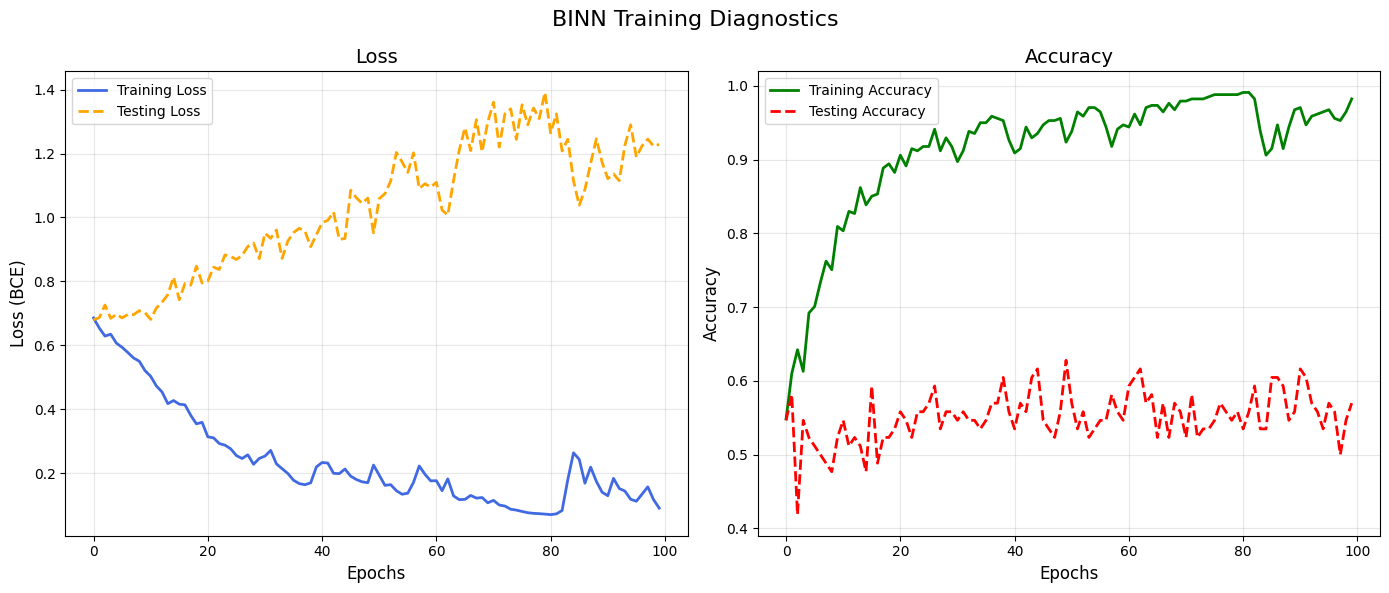

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Loss plot
axes[0].plot(history['train_loss'], label='Training Loss', color='royalblue', linewidth=2)
axes[0].plot(history['test_loss'], label='Testing Loss', color='orange', linestyle='--', linewidth=2)
axes[0].set_title('Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss (BCE)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Training Accuracy', color='green', linewidth=2)
axes[1].plot(history['test_acc'], label='Testing Accuracy', color='red', linestyle='--', linewidth=2)
axes[1].set_title('Accuracy', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('BINN Training Diagnostics', fontsize=16)
plt.tight_layout()
plt.show()

In [30]:
# CROSS VALIDATION
all_fold_scores = dh.run_cross_validation(adata_global, in_features, layers_list, tensor_masks, device, k=5, epochs=75)


--- Starting Fold 1/5 ---
Fold 1 Best Test AUC: 0.6502

--- Starting Fold 2/5 ---
Fold 2 Best Test AUC: 0.6738

--- Starting Fold 3/5 ---
Fold 3 Best Test AUC: 0.6425

--- Starting Fold 4/5 ---
Fold 4 Best Test AUC: 0.7133

--- Starting Fold 5/5 ---
Fold 5 Best Test AUC: 0.6170

Mean ROC-AUC: 0.6594 +/- 0.0325


In [ ]:
"""
import optuna
def objective(trial):
    # Let Optuna suggest the hyperparameters for this run
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True)
    
    # Run your existing CV function, passing the suggested params
    # Note: You will need to modify run_cross_validation to accept these as arguments
    fold_aucs = dh.run_cross_validation(adata_global, in_features, layers_list, tensor_masks, 
                                        device, k=5, epochs=75, lr=lr, weight_decay=weight_decay)
    
    mean_auc = np.mean(fold_aucs)
    
    # Optuna will try to MAXIMIZE this returned value
    return mean_auc

# Create the study and optimize!
print("Starting Optuna Hyperparameter Search...")
study = optuna.create_study(direction="maximize")

# Run 30 trials (takes time, but worth it)
study.optimize(objective, n_trials=30)

# View the results
print("\n=== Best Hyperparameters ===")
print(study.best_params)
print(f"Best Mean CV ROC-AUC: {study.best_value:.4f}")

# Best recorded: {'lr': 0.0017772099~1.778e-3, 'weight_decay': 0.025921115~2.592e-2}
"""

[I 2026-04-26 12:29:48,654] A new study created in memory with name: no-name-80fc399e-b903-47d3-8ed9-4a9ed5e1eea8


Starting Optuna Hyperparameter Search...

--- Starting Fold 1/5 ---
Fold 1 Best Test AUC: 0.6963

--- Starting Fold 2/5 ---
Fold 2 Best Test AUC: 0.6206

--- Starting Fold 3/5 ---
Fold 3 Best Test AUC: 0.7083

--- Starting Fold 4/5 ---
Fold 4 Best Test AUC: 0.6792

--- Starting Fold 5/5 ---


[I 2026-04-26 12:30:03,286] Trial 0 finished with value: 0.6713372527062338 and parameters: {'lr': 4.008841014742689e-05, 'weight_decay': 0.000716099104992246}. Best is trial 0 with value: 0.6713372527062338.


Fold 5 Best Test AUC: 0.6523

Mean ROC-AUC: 0.6713 +/- 0.0316

--- Starting Fold 1/5 ---
Fold 1 Best Test AUC: 0.6842

--- Starting Fold 2/5 ---
Fold 2 Best Test AUC: 0.6859

--- Starting Fold 3/5 ---
Fold 3 Best Test AUC: 0.6672

--- Starting Fold 4/5 ---
Fold 4 Best Test AUC: 0.6702

--- Starting Fold 5/5 ---


[I 2026-04-26 12:30:17,838] Trial 1 finished with value: 0.6733045685663267 and parameters: {'lr': 0.00013673800708560507, 'weight_decay': 0.014831840853011667}. Best is trial 1 with value: 0.6733045685663267.


...

Fold 5 Best Test AUC: 0.6512

Mean ROC-AUC: 0.6685 +/- 0.0168

--- Starting Fold 1/5 ---
Fold 1 Best Test AUC: 0.6634

--- Starting Fold 2/5 ---
Fold 2 Best Test AUC: 0.7297

--- Starting Fold 3/5 ---
Fold 3 Best Test AUC: 0.6943

--- Starting Fold 4/5 ---
Fold 4 Best Test AUC: 0.6293

--- Starting Fold 5/5 ---


[I 2026-04-26 12:37:03,756] Trial 28 finished with value: 0.671557118428619 and parameters: {'lr': 0.0018286479300082187, 'weight_decay': 0.00036598842954563765}. Best is trial 26 with value: 0.6928697804747637.


Fold 5 Best Test AUC: 0.6411

Mean ROC-AUC: 0.6716 +/- 0.0365

--- Starting Fold 1/5 ---
Fold 1 Best Test AUC: 0.6902

--- Starting Fold 2/5 ---
Fold 2 Best Test AUC: 0.5976

--- Starting Fold 3/5 ---
Fold 3 Best Test AUC: 0.6357

--- Starting Fold 4/5 ---
Fold 4 Best Test AUC: 0.6249

--- Starting Fold 5/5 ---


[I 2026-04-26 12:37:18,420] Trial 29 finished with value: 0.6223314089565489 and parameters: {'lr': 3.565508474319613e-05, 'weight_decay': 0.003189889376510729}. Best is trial 26 with value: 0.6928697804747637.


Fold 5 Best Test AUC: 0.5633

Mean ROC-AUC: 0.6223 +/- 0.0422

=== Best Hyperparameters ===
{'lr': 0.001777209913333319, 'weight_decay': 0.025921115648927306}
Best Mean CV ROC-AUC: 0.6929
